# Customer Segmentation Using DBSCAN

## Project Information

**Dataset:** Mall Customer Segmentation Dataset

**Author:** Muhammad Anas

**Project Type:** Unsupervised Machine Learning

**Algorithm:** DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

---

## Project Objective

The objective of this project is to segment customers into different groups based on their Annual Income and Spending Score using the DBSCAN clustering algorithm. DBSCAN identifies clusters based on the density of data points and can automatically detect outliers or noise.

---

## About DBSCAN

DBSCAN is a density-based clustering algorithm that groups closely packed data points into clusters while labeling isolated points as noise. Unlike K-Means, DBSCAN does not require specifying the number of clusters beforehand.

---

## Key Concepts

### Epsilon (eps)

The maximum distance between two points for them to be considered neighbors.

### MinPts (min_samples)

The minimum number of points required within the epsilon radius to form a cluster.

### Core Point

A point that has at least MinPts neighbors within its epsilon radius.

### Border Point

A point that belongs to a cluster but does not have enough neighbors to be a core point.

### Noise Point

An isolated point that does not belong to any cluster.

---

## Features Used

- Annual Income (k$)
- Spending Score (1-100)

---

## Expected Outcomes

- Identify customer groups automatically
- Detect outliers or unusual customers
- Understand customer spending behavior
- Compare DBSCAN results with K-Means and Hierarchical Clustering

---

## Evaluation Metric

### Silhouette Score

Measures how well-separated the clusters are.

Interpretation:

- Close to 1 → Excellent Clustering
- Around 0 → Overlapping Clusters
- Less than 0 → Poor Clustering

---

## Advantages of DBSCAN

- No need to specify the number of clusters
- Detects outliers automatically
- Handles irregularly shaped clusters
- Works well with noisy datasets



In [9]:
#importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

In [2]:
#Loading the dataset 
df=pd.read_csv('D:\\DATA_SCIENCE_PROJECTS\\Ml_Algorathims\\Unsupervised_Machine_Learning\\Dataset\\Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
#renaming the Anuual Income and the Spending Score columns
df.rename(columns={
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
}, inplace=True)

df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
#selecting the numeric features
X=df[['Annual_Income','Spending_Score']]
X.head()

,Annual_Income,Spending_Score
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [15]:
#Applying the DBSCAN algorathim
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=2,
    min_samples=5
)

clusters = dbscan.fit_predict(X)

df['Cluster'] = clusters

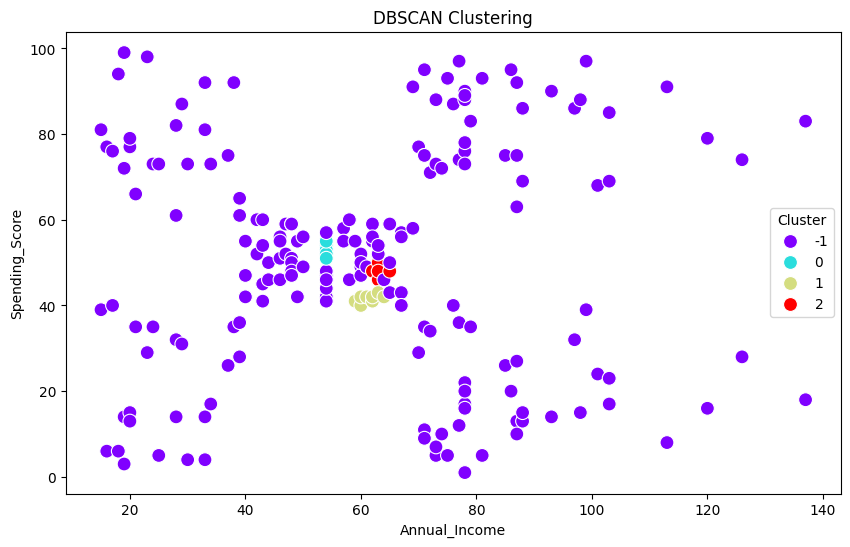

In [16]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Annual_Income',
    y='Spending_Score',
    hue='Cluster',
    data=df,
    palette='rainbow',
    s=100
)

plt.title('DBSCAN Clustering')
plt.show()

In [17]:
#checking for the unique value of the cluster 
print(df['Cluster'].value_counts())

Cluster
-1    182
 1      8
 0      5
 2      5
Name: count, dtype: int64


In [18]:
#checking for the silhouette score
print(silhouette_score(X,clusters))

-0.3384933492468103
